# EDA Completo: Determinantes del Éxito Competitivo en CS:GO
**Proyecto:** Regresión Logística Bayesiana Jerárquica  
**Autores:** Julián Duarte, Julián Jiménez, Tomás Rincón  
**Curso:** Pensamiento Crítico 2 — Estadística Bayesiana  

## Objetivo del EDA
1. Identificar las variables críticas que separan a ganadores de perdedores.
2. Justificar la selección de predictores para el modelo bayesiano jerárquico.
3. Evidenciar la necesidad de una estructura jerárquica por mapa.
4. Evaluar multicolinealidad y calidad de los datos.
5. Proporcionar visualizaciones clave para el paper final.


## 0. Configuración y Carga de Datos

In [2]:
1+1

2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 12
})

PALETTE = {'win': '#2ecc71', 'loss': '#e74c3c'}

PATH_GAMES = 'datos/csgo_games.csv'
PATH_RESULTS = '../data/raw/results.csv'
df = pd.read_csv(PATH_GAMES)
df_res = pd.read_csv(PATH_RESULTS)

print(f"Partidas (csgo_games): {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Rondas (results): {df_res.shape[0]} filas, {df_res.shape[1]} columnas")


Partidas (csgo_games): 3787 filas, 170 columnas
Rondas (results): 45773 filas, 19 columnas


## 0.1 Ingeniería de Variables

In [4]:
metrics = ['rating', 'impact', 'kdr', 'dmr', 'kpr', 'apr', 'dpr', 'spr',
           'clutch_win_perc', 'multikill_perc', 'opk_ratio', 'opk_rating']
for team in ['t1', 't2']:
    for m in metrics:
        cols = [f"{team}_player{i}_{m}" for i in range(1, 6)]
        existing = [c for c in cols if c in df.columns]
        if len(existing) == 5:
            df[f"{team}_avg_{m}"] = df[existing].mean(axis=1)

for m in metrics:
    c1, c2 = f"t1_avg_{m}", f"t2_avg_{m}"
    if c1 in df.columns and c2 in df.columns:
        df[f"diff_{m}"] = df[c1] - df[c2]

df['target_t1_win'] = np.where(df['winner'] == 't1', 1,
                                np.where(df['winner'] == 't2', 0, np.nan))
df['diff_rank'] = df['t1_world_rank'] - df['t2_world_rank']
df['diff_h2h'] = df['t1_h2h_win_perc'] - df['t2_h2h_win_perc']

# KAST compuesto
if all(c in df.columns for c in ['t1_avg_kpr', 't1_avg_apr', 't1_avg_spr']):
    df['t1_avg_kast'] = df['t1_avg_kpr'] + df['t1_avg_apr'] + df['t1_avg_spr']
    df['t2_avg_kast'] = df['t2_avg_kpr'] + df['t2_avg_apr'] + df['t2_avg_spr']
    df['diff_kast'] = df['t1_avg_kast'] - df['t2_avg_kast']

print(f"Target distribution:\n{df['target_t1_win'].value_counts(normalize=True)}")


Target distribution:
target_t1_win
1.0    0.510497
0.0    0.489503
Name: proportion, dtype: float64


---
## 1. Análisis Univariado
### 1.1 Estadísticas Descriptivas

In [5]:
desc_vars = ['diff_rating', 'diff_impact', 'diff_kdr', 'diff_dmr',
               'diff_kpr', 'diff_rank', 'diff_h2h', 'diff_kast']
existing_desc = [v for v in desc_vars if v in df.columns]
desc = df[existing_desc].describe().T
desc['missing'] = df[existing_desc].isnull().sum()
desc['missing_pct'] = (desc['missing'] / len(df)) * 100
desc


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
diff_rating,3787.0,0.003183,0.061418,-0.250,-0.036000,0.004,0.042000,0.250,0,0.0
diff_impact,3787.0,0.002835,0.064822,-0.324,-0.036000,0.002,0.043000,0.282,0,0.0
diff_kdr,3787.0,0.005510,0.088993,-0.366,-0.052000,0.004,0.062000,0.366,0,0.0
diff_dmr,3787.0,0.123396,2.596121,-16.520,-1.460000,0.160,1.780000,12.560,0,0.0
diff_kpr,3787.0,0.001225,0.029357,-0.108,-0.016000,0.002,0.020000,0.114,0,0.0
diff_rank,3787.0,-0.999736,7.566940,-20.000,-6.000000,-1.000,4.000000,19.000,0,0.0
diff_h2h,3787.0,0.035560,0.457626,-1.000,-0.220867,0.000,0.333333,1.000,0,0.0
diff_kast,3787.0,0.001114,0.038844,-0.152,-0.024000,0.002,0.026000,0.162,0,0.0


### 1.2 Distribuciones de las Métricas Clave por Resultado

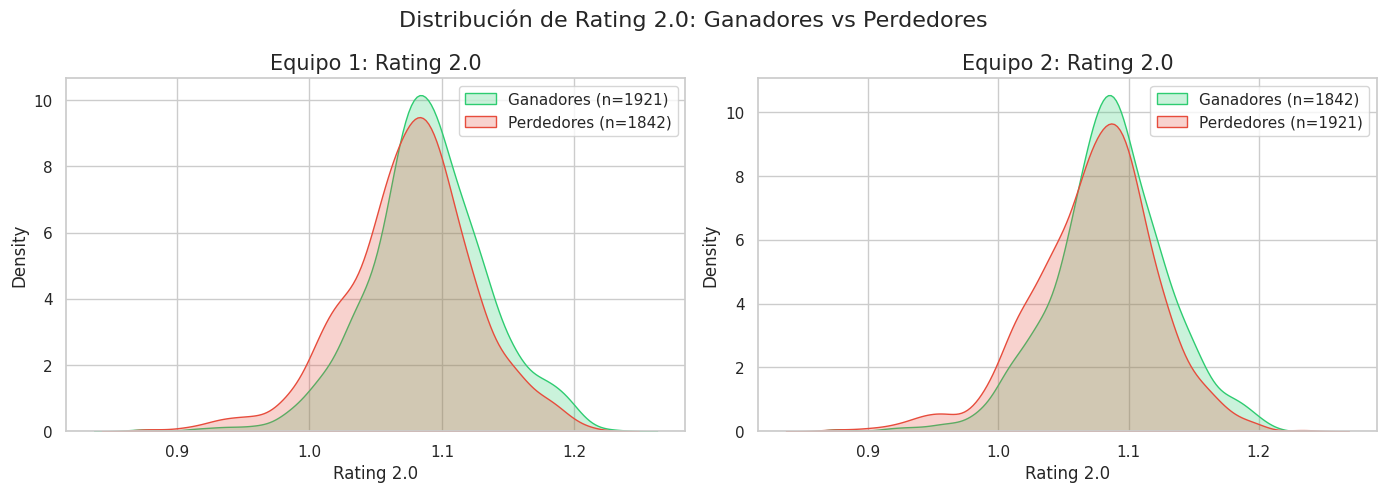

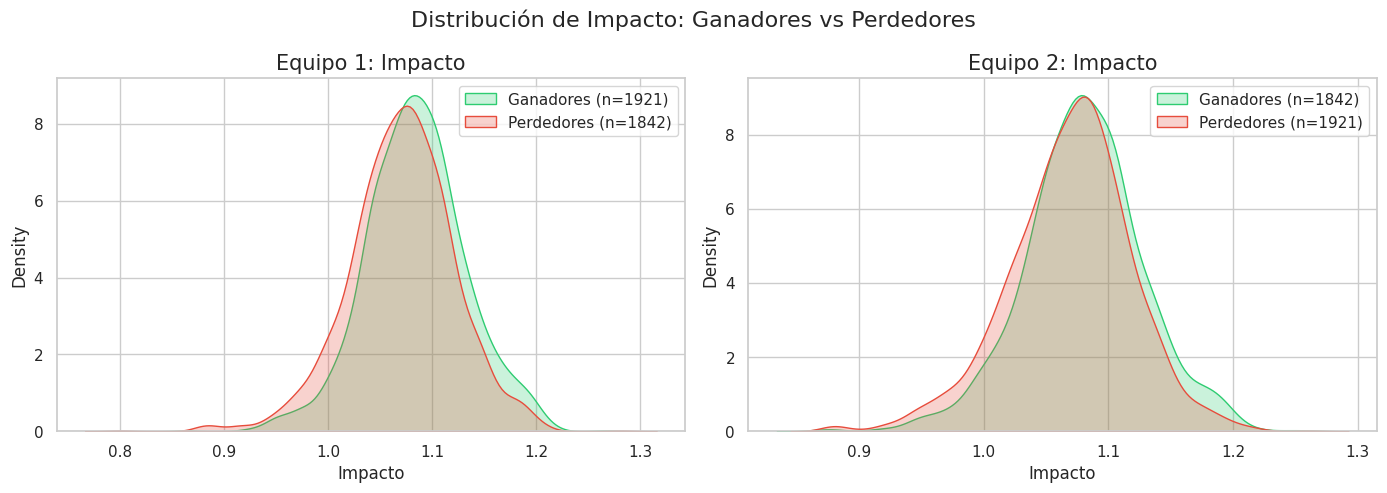

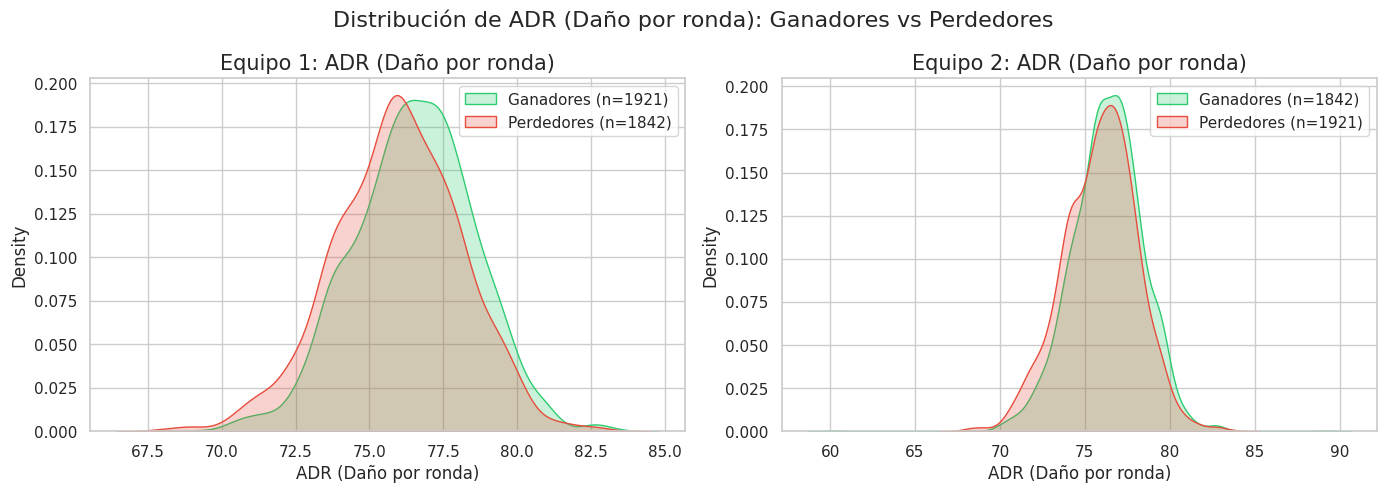

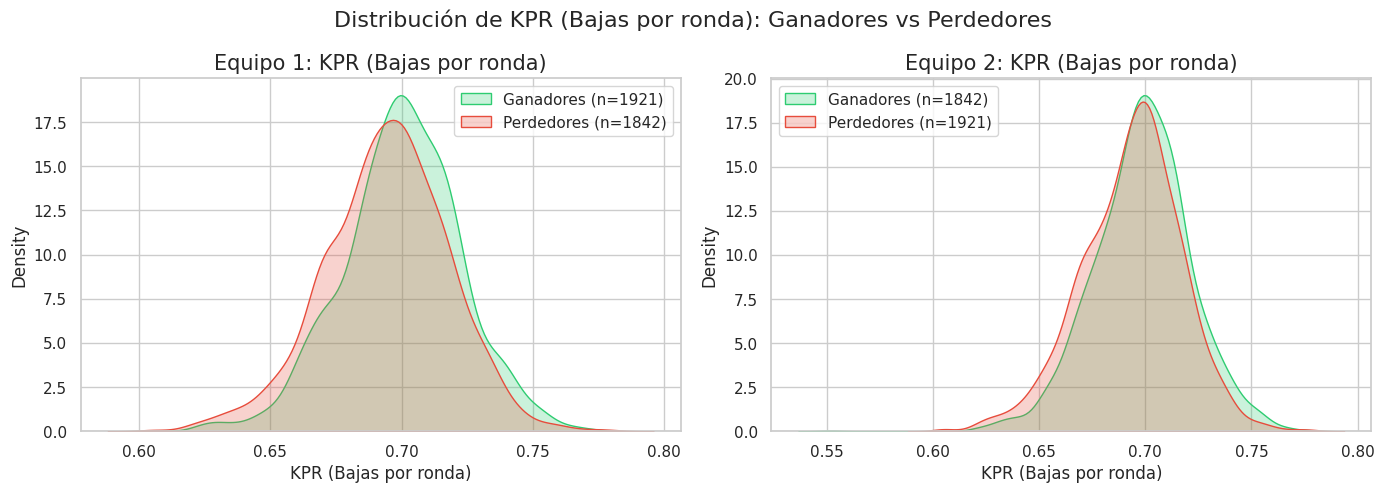

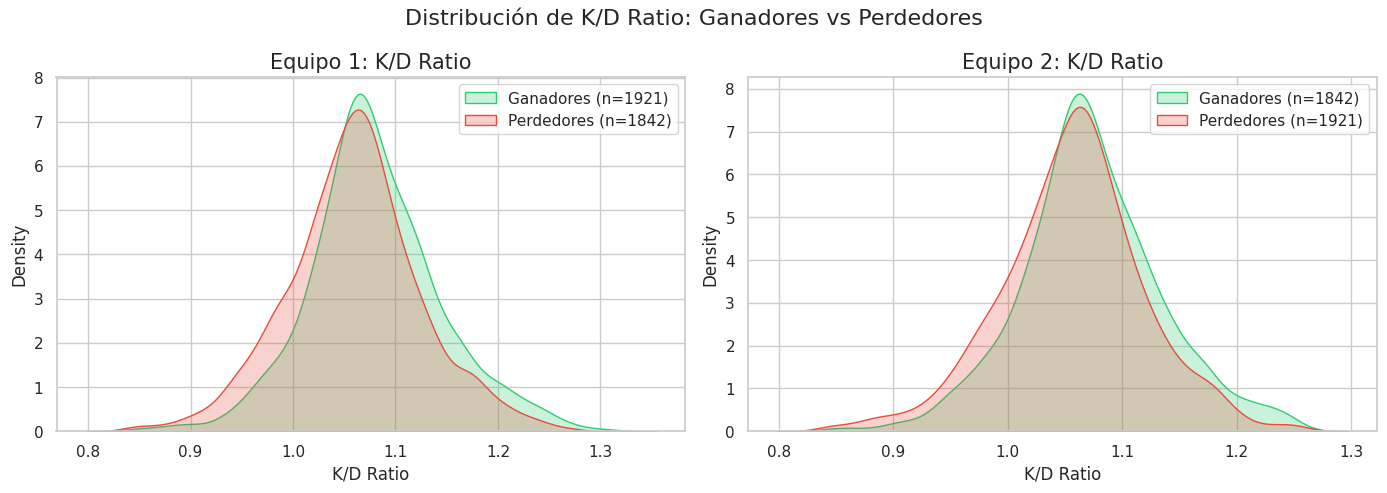

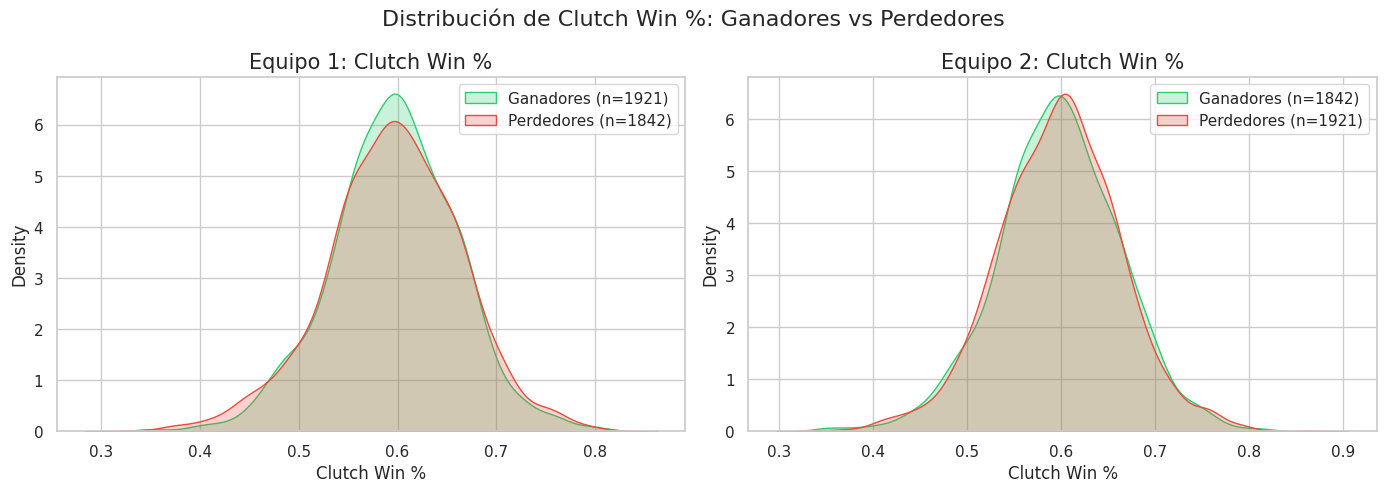

In [6]:
def plot_density_comparison(var, label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, team_prefix, color, team_label in zip(
        axes, ['t1', 't2'], ['#3498db', '#e67e22'], ['Equipo 1', 'Equipo 2']):
        col = f"{team_prefix}_avg_{var}"
        if col not in df.columns:
            ax.set_title(f"{team_label}: {var} - No disponible")
            continue
        mask_win = df['winner'] == team_prefix
        mask_loss = (df['winner'] == ('t2' if team_prefix == 't1' else 't1'))
        data_win = df.loc[mask_win, col].dropna()
        data_loss = df.loc[mask_loss, col].dropna()
        sns.kdeplot(data_win, ax=ax, fill=True, color='#2ecc71',
                    label=f'Ganadores (n={len(data_win)})')
        sns.kdeplot(data_loss, ax=ax, fill=True, color='#e74c3c',
                    label=f'Perdedores (n={len(data_loss)})')
        ax.set_title(f"{team_label}: {label}")
        ax.set_xlabel(label)
        ax.legend()
    plt.suptitle(f'Distribución de {label}: Ganadores vs Perdedores', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'images/distribucion_{var}_comparada.png', dpi=300, bbox_inches='tight')
    plt.show()

for var, label in [('rating', 'Rating 2.0'), ('impact', 'Impacto'),
                   ('dmr', 'ADR (Daño por ronda)'), ('kpr', 'KPR (Bajas por ronda)'),
                   ('kdr', 'K/D Ratio'), ('clutch_win_perc', 'Clutch Win %')]:
    plot_density_comparison(var, label)


### 1.3 Valores Atípicos y Calidad del Dato

In [7]:
def detect_outliers_iqr(df, cols):
    results = []
    for col in cols:
        if col not in df.columns:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        results.append({
            'Variable': col,
            'Outliers': len(outliers),
            'Porcentaje': f"{100 * len(outliers) / len(df):.1f}%",
            'Min': f"{lower:.3f}",
            'Max': f"{upper:.3f}"
        })
    return pd.DataFrame(results)

outlier_vars = [v for v in ['diff_rating', 'diff_impact', 'diff_kdr', 'diff_dmr',
                            'diff_kpr', 'diff_rank'] if v in df.columns]
detect_outliers_iqr(df, outlier_vars)


,Variable,Outliers,Porcentaje,Min,Max
0,diff_rating,49,1.3%,-0.153,0.159
1,diff_impact,84,2.2%,-0.155,0.162
2,diff_kdr,50,1.3%,-0.223,0.233
3,diff_dmr,55,1.5%,-6.320,6.640
4,diff_kpr,77,2.0%,-0.070,0.074
5,diff_rank,0,0.0%,-21.000,19.000


---
## 2. Análisis Bivariado
### 2.1 Correlación con la Victoria

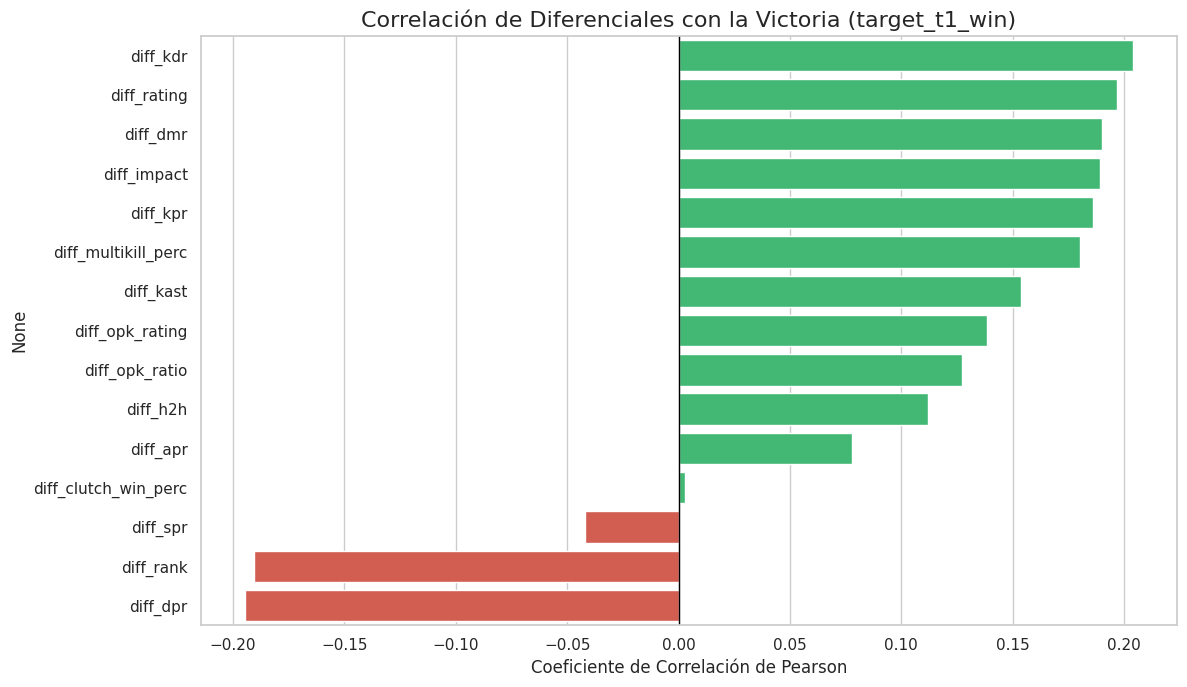


Variables con mayor poder predictivo (|r| > 0.15):
  diff_kdr              r = +0.2038
  diff_rating           r = +0.1969
  diff_dmr              r = +0.1901
  diff_impact           r = +0.1892
  diff_kpr              r = +0.1860
  diff_multikill_perc   r = +0.1800
  diff_kast             r = +0.1537
  diff_rank             r = -0.1907
  diff_dpr              r = -0.1945


In [8]:
diff_cols = [c for c in df.columns if c.startswith('diff_')]
available = diff_cols + ['target_t1_win']
available = [c for c in available if c in df.columns]
corr_data = df[available].corr()
target_corr = corr_data['target_t1_win'].drop('target_t1_win').sort_values(ascending=False)

plt.figure(figsize=(12, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.values]
sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)
plt.title('Correlación de Diferenciales con la Victoria (target_t1_win)', fontsize=16)
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('images/correlacion_victoria_barras.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVariables con mayor poder predictivo (|r| > 0.15):")
for var, corr_val in target_corr.items():
    if abs(corr_val) > 0.15:
        print(f"  {var:20s}  r = {corr_val:+.4f}")


### 2.2 Empirical Logit Plots (Justificación Regresión Logística)

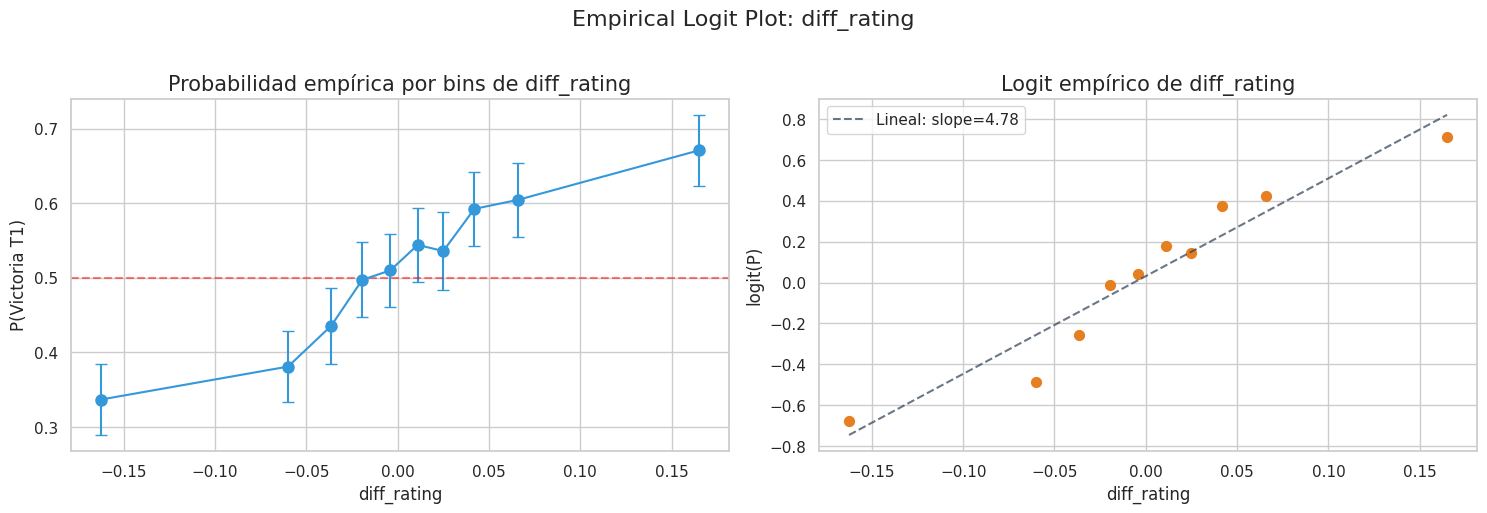

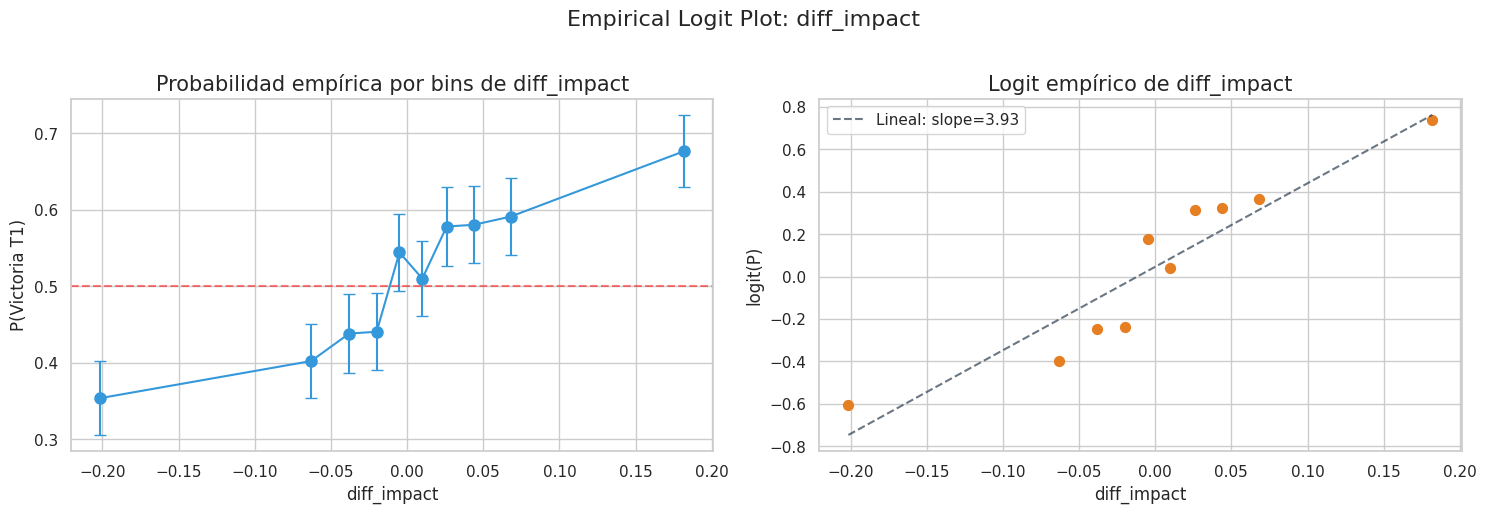

In [9]:
def empirical_logit_plot(df, var, target, n_bins=10):
    df_plot = df[[var, target]].dropna()
    df_plot['bin'] = pd.qcut(df_plot[var], q=n_bins, duplicates='drop')
    agg = df_plot.groupby('bin')[target].agg(['mean', 'count'])
    agg['logit'] = np.log(agg['mean'] / (1 - agg['mean'] + 1e-10))
    agg['bin_center'] = [interval.mid for interval in agg.index]
    agg = agg[agg['count'] >= 10]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].errorbar(agg['bin_center'], agg['mean'],
                     yerr=1.96 * np.sqrt(agg['mean'] * (1 - agg['mean']) / agg['count']),
                     fmt='o-', capsize=4, color='#3498db', markersize=8)
    axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5)
    axes[0].set_xlabel(var); axes[0].set_ylabel('P(Victoria T1)')
    axes[0].set_title(f'Probabilidad empírica por bins de {var}')
    axes[1].scatter(agg['bin_center'], agg['logit'], color='#e67e22', s=50)
    mask_valid = ~np.isinf(agg['logit'])
    if mask_valid.sum() > 2:
        z = np.polyfit(agg['bin_center'][mask_valid], agg['logit'][mask_valid], 1)
        p = np.poly1d(z)
        x_line = np.linspace(agg['bin_center'].min(), agg['bin_center'].max(), 100)
        axes[1].plot(x_line, p(x_line), '--', color='#2c3e50', alpha=0.7,
                     label=f'Lineal: slope={z[0]:.2f}')
        axes[1].legend()
    axes[1].set_xlabel(var); axes[1].set_ylabel('logit(P)')
    axes[1].set_title(f'Logit empírico de {var}')
    plt.suptitle(f'Empirical Logit Plot: {var}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(f'images/empirical_logit_{var}.png', dpi=300, bbox_inches='tight')
    plt.show()

for var in ['diff_rating', 'diff_impact']:
    if var in df.columns:
        empirical_logit_plot(df, var, 'target_t1_win')


### 2.3 Winrate por Decil con Intervalos Bootstrap

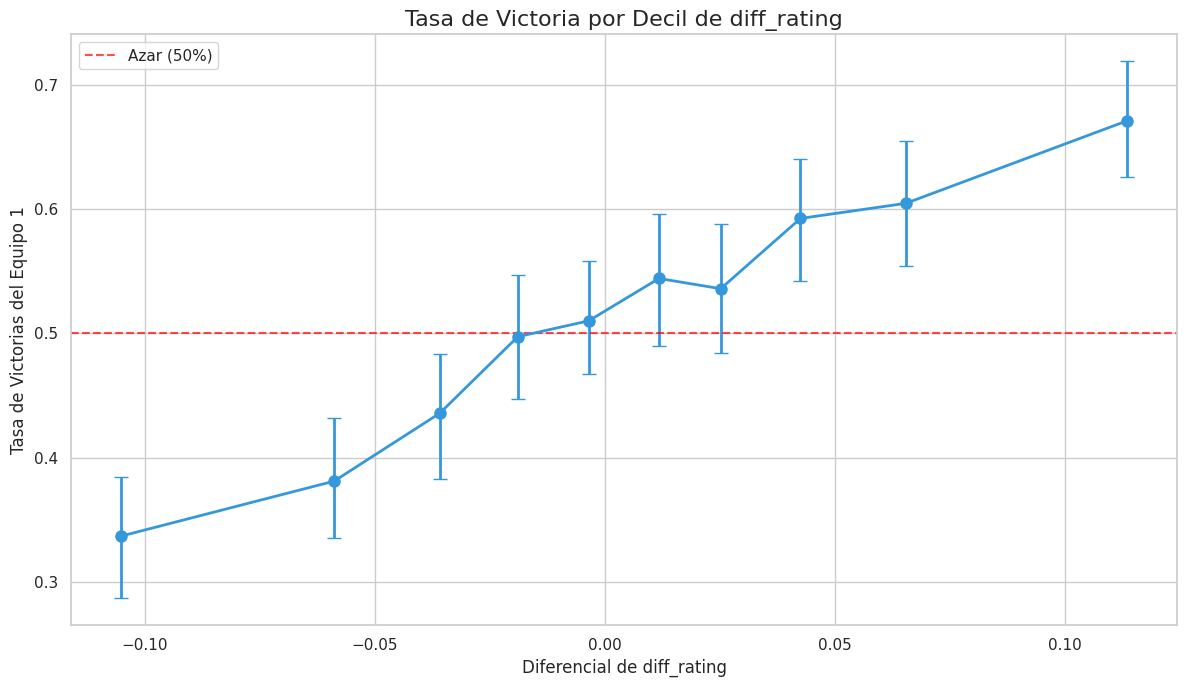

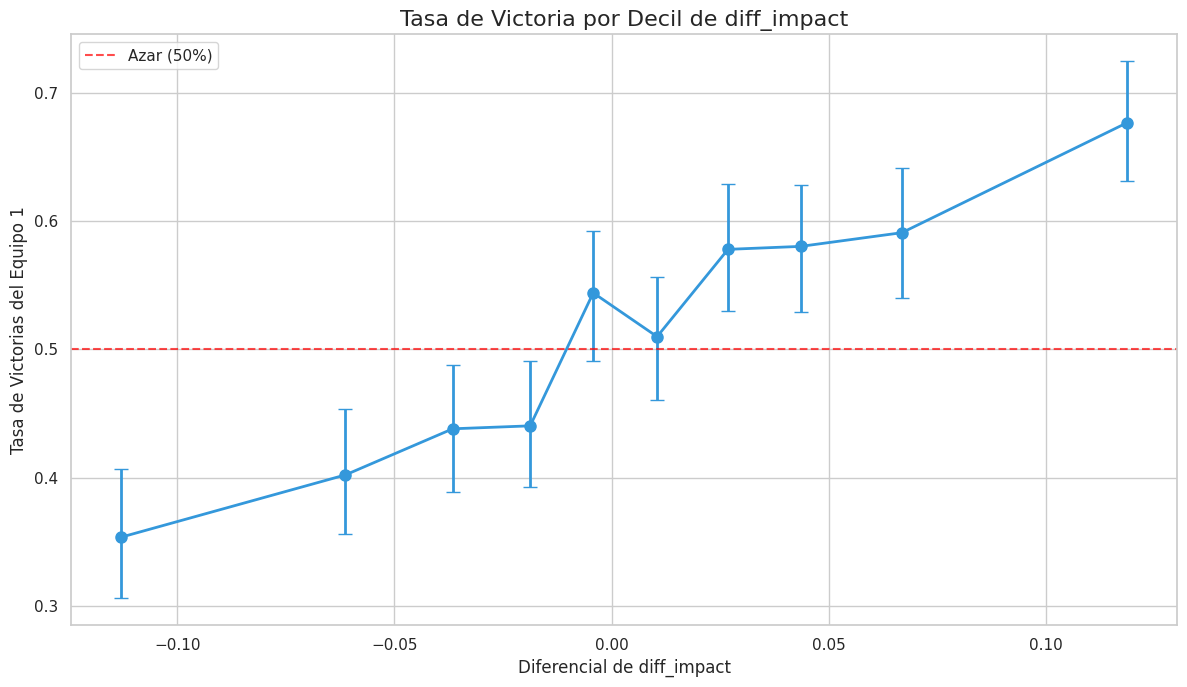

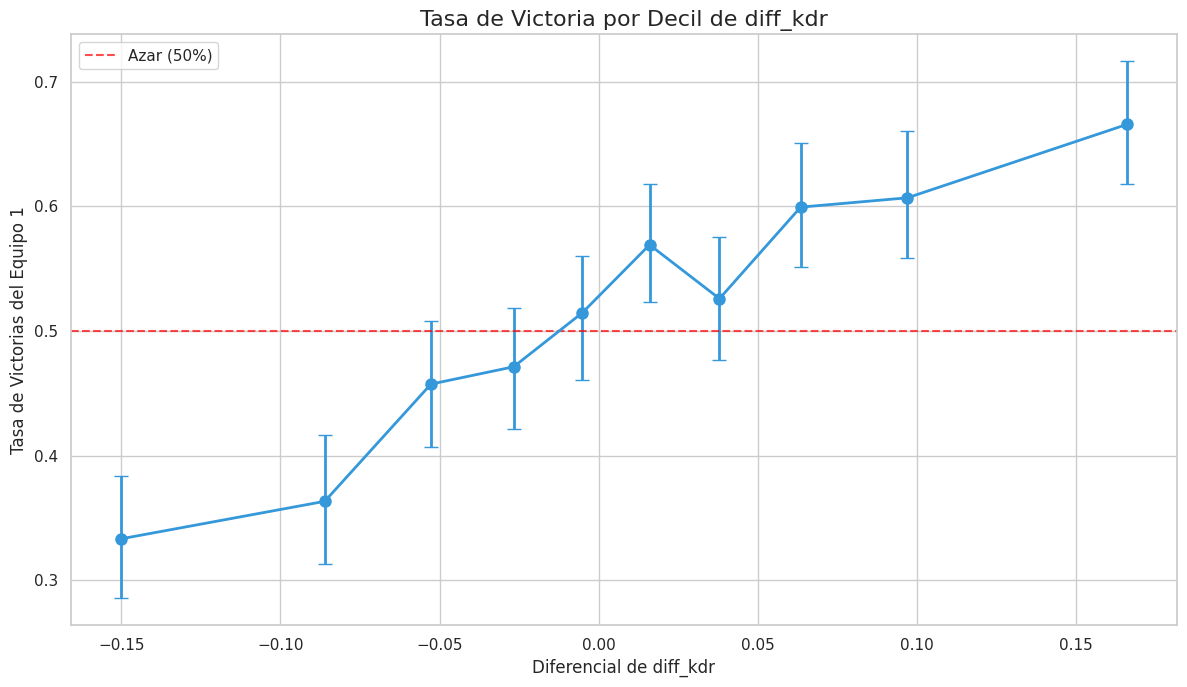

In [10]:
def decile_winrate_plot(df, var, target, n_deciles=10):
    df_plot = df[[var, target]].dropna()
    df_plot['decil'] = pd.qcut(df_plot[var], q=n_deciles, labels=False, duplicates='drop')
    np.random.seed(42)
    results = []
    for d in sorted(df_plot['decil'].unique()):
        subset = df_plot[df_plot['decil'] == d]
        wr = subset[target].mean()
        boot_wr = []
        for _ in range(1000):
            boot_wr.append(subset.sample(n=len(subset), replace=True)[target].mean())
        ci_low, ci_high = np.percentile(boot_wr, [2.5, 97.5])
        results.append({'decil': d, 'winrate': wr, 'ci_low': ci_low,
                        'ci_high': ci_high, 'bin_mid': subset[var].mean(), 'n': len(subset)})
    res_df = pd.DataFrame(results)
    plt.figure(figsize=(12, 7))
    plt.errorbar(res_df['bin_mid'], res_df['winrate'],
                 yerr=[res_df['winrate'] - res_df['ci_low'],
                       res_df['ci_high'] - res_df['winrate']],
                 fmt='o-', capsize=5, color='#3498db', markersize=8, linewidth=2)
    plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Azar (50%)')
    plt.xlabel(f'Diferencial de {var}'); plt.ylabel('Tasa de Victorias del Equipo 1')
    plt.title(f'Tasa de Victoria por Decil de {var}', fontsize=16)
    plt.legend(); plt.tight_layout()
    plt.savefig(f'images/winrate_decil_{var}.png', dpi=300, bbox_inches='tight')
    plt.show()

for var in ['diff_rating', 'diff_impact', 'diff_kdr']:
    if var in df.columns:
        decile_winrate_plot(df, var, 'target_t1_win')


---
## 3. Análisis de Estructura Jerárquica (Mapas)
La hipótesis central es que cada mapa tiene asimetrías tácticas únicas que modifican la importancia de los predictores.

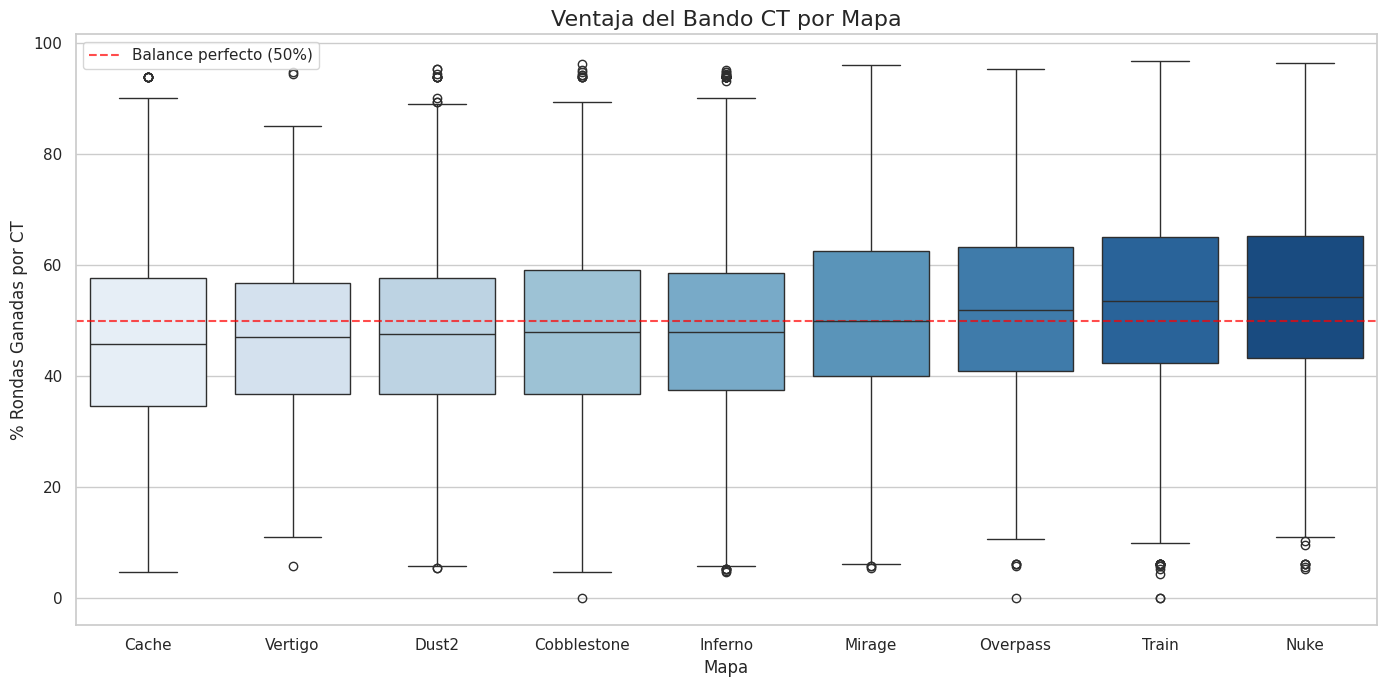

Balance CT/T por Mapa:


,Promedio_CT,Mediana_CT,Std_CT,Partidas,Ventaja_CT
_map,,,,,
Nuke,54.0,54.2,15.5,4206,4.0
Train,53.3,53.6,16.1,6566,3.3
Overpass,52.0,51.9,15.5,5625,2.0
Mirage,51.0,50.0,15.5,9021,1.0
Inferno,48.4,48.0,15.4,7485,-1.6
Cobblestone,48.3,48.0,16.1,3513,-1.7
Dust2,47.6,47.6,15.4,4114,-2.4
Vertigo,47.2,47.1,14.3,609,-2.8
Cache,46.7,45.8,16.2,4613,-3.3


In [11]:
df_res['total_rondas'] = df_res['result_1'] + df_res['result_2']
df_res['ct_rondas'] = df_res['ct_1'] + df_res['ct_2']
df_res['ct_winrate'] = (df_res['ct_rondas'] / df_res['total_rondas']) * 100

common_maps = df_res['_map'].value_counts().head(10).index
tier1_maps = [m for m in common_maps if m != 'Default']
df_map = df_res[df_res['_map'].isin(tier1_maps)]

plt.figure(figsize=(14, 7))
order = df_map.groupby('_map')['ct_winrate'].median().sort_values().index
sns.boxplot(data=df_map, x='_map', y='ct_winrate', order=order, palette='Blues')
plt.axhline(50, color='red', linestyle='--', alpha=0.7, label='Balance perfecto (50%)')
plt.title('Ventaja del Bando CT por Mapa', fontsize=16)
plt.ylabel('% Rondas Ganadas por CT'); plt.xlabel('Mapa'); plt.legend()
plt.tight_layout()
plt.savefig('images/balance_ct_t_mapas.png', dpi=300, bbox_inches='tight')
plt.show()

map_stats = df_map.groupby('_map').agg(
    Promedio_CT=('ct_winrate', 'mean'), Mediana_CT=('ct_winrate', 'median'),
    Std_CT=('ct_winrate', 'std'), Partidas=('ct_winrate', 'count')
).round(1)
map_stats['Ventaja_CT'] = map_stats['Promedio_CT'] - 50
map_stats = map_stats.sort_values('Promedio_CT', ascending=False)
print("Balance CT/T por Mapa:")
map_stats


**Conclusión sobre estructura jerárquica:**  
El análisis de `results.csv` confirma **asimetrías tácticas significativas** entre mapas (Nuke fuertemente CT-sided vs Mirage balanceado). Esto justifica el uso de interceptos aleatorios por mapa en el modelo jerárquico. El dataset `csgo_games.csv` no incluye la variable de mapa directamente, por lo que para el modelo final será necesario enlazar ambos datasets.

---
## 4. Análisis Temporal

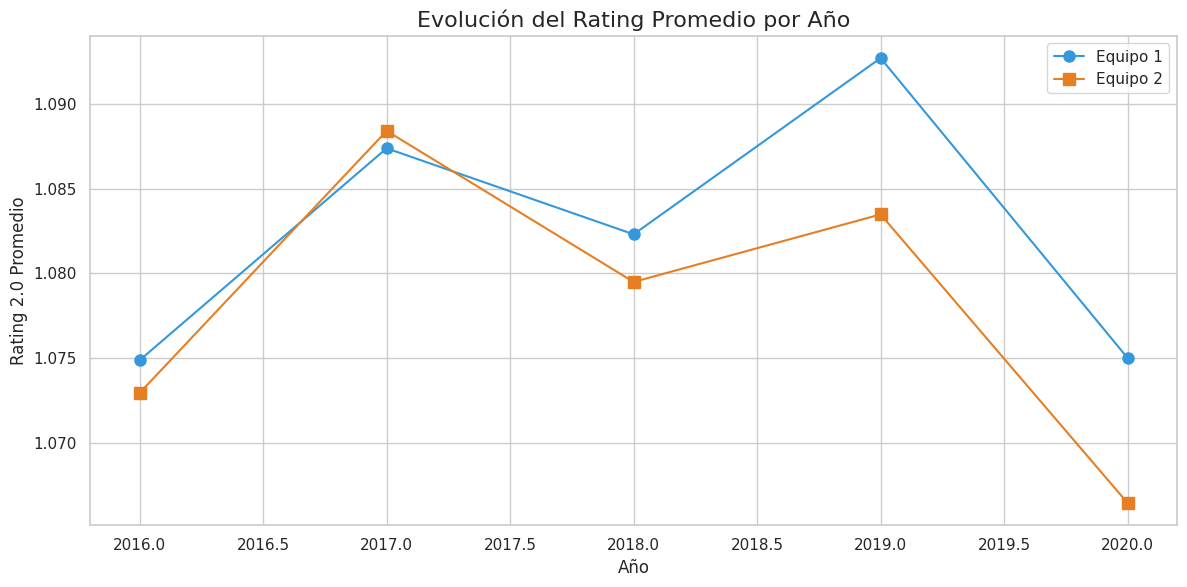

In [12]:
if 'match_date' in df.columns:
    df['match_date'] = pd.to_datetime(df['match_date'])
    df['year'] = df['match_date'].dt.year
    yearly = df.groupby('year')[['t1_avg_rating', 't2_avg_rating']].mean()
    plt.figure(figsize=(12, 6))
    plt.plot(yearly.index, yearly['t1_avg_rating'], 'o-', color='#3498db',
             label='Equipo 1', markersize=8)
    plt.plot(yearly.index, yearly['t2_avg_rating'], 's-', color='#e67e22',
             label='Equipo 2', markersize=8)
    plt.title('Evolución del Rating Promedio por Año', fontsize=16)
    plt.xlabel('Año'); plt.ylabel('Rating 2.0 Promedio'); plt.legend()
    plt.tight_layout()
    plt.savefig('images/evolucion_rating_anual.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Columna 'match_date' no disponible")


---
## 5. Multicolinealidad y Selección de Predictores

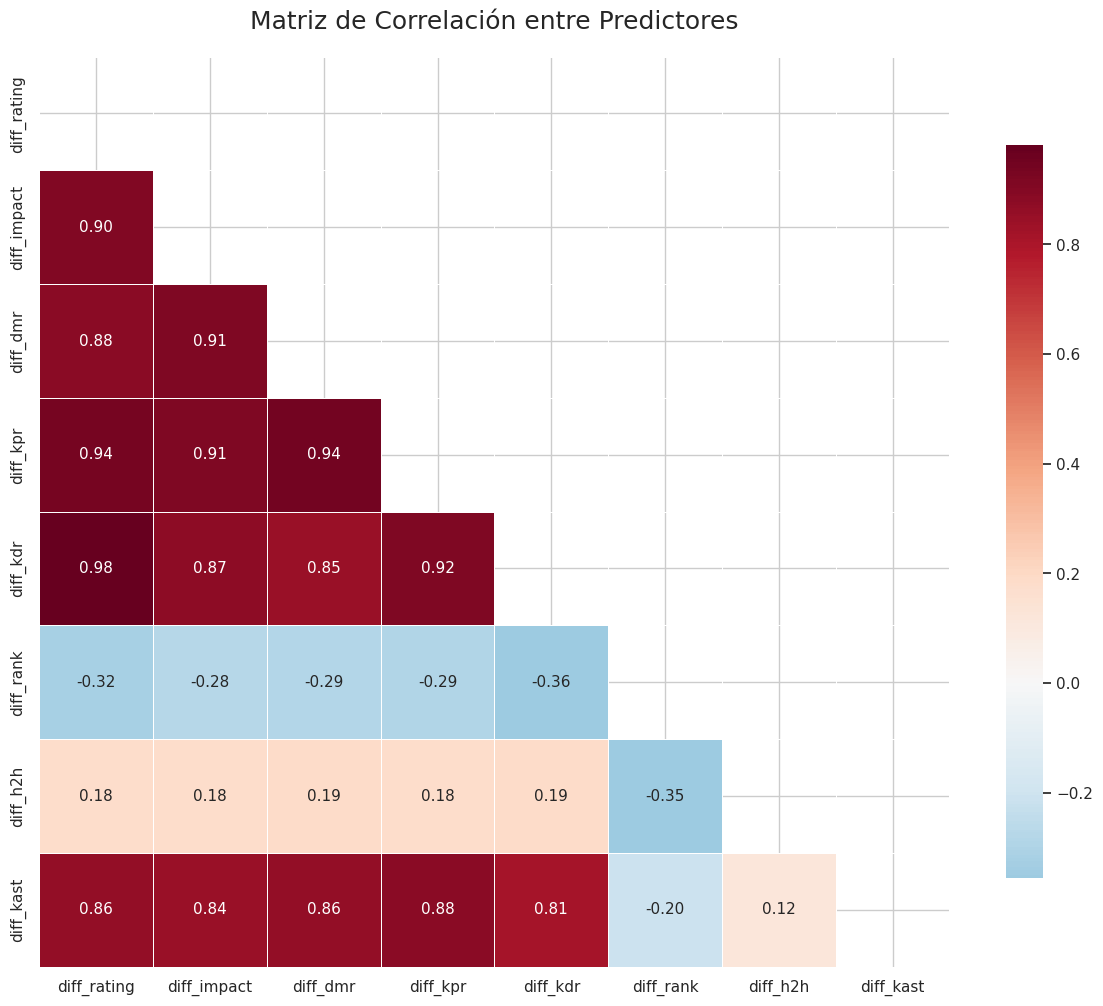

In [13]:
corr_vars = [v for v in ['diff_rating', 'diff_impact', 'diff_dmr', 'diff_kpr',
                          'diff_kdr', 'diff_rank', 'diff_h2h', 'diff_kast']
              if v in df.columns]
corr_matrix = df[corr_vars].corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Predictores', fontsize=18, pad=20)
plt.tight_layout()
plt.savefig('images/matriz_correlacion_completa.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_vars = [v for v in ['diff_rating', 'diff_impact', 'diff_dmr', 'diff_kpr',
                         'diff_kdr', 'diff_rank'] if v in df.columns]
vif_data = df[vif_vars].dropna()
X = add_constant(vif_data)
vif_df = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_df = vif_df[vif_df['Variable'] != 'const']
print("VIF: >10 severa, >5 moderada")
vif_df


VIF: >10 severa, >5 moderada


,Variable,VIF
1,diff_rating,41.117771
2,diff_impact,8.232683
3,diff_dmr,10.762891
4,diff_kpr,17.103724
5,diff_kdr,30.453365
6,diff_rank,1.182494


### 5.1 Selección Final de Predictores

| Predictor | r con Victoria | Seleccionado | Justificación |
|:---|---:|:---|:---|
| diff_rating | más alto | Sí | Métrica integral de rendimiento |
| diff_impact | alto | Sí | Captura momentos críticos |
| diff_dmr (ADR) | alto | Sí | Daño infligido por ronda |
| diff_kast | moderado | Sí | Contribución consistente |
| diff_rank | moderado | Opcional | Control por ranking |
| diff_kdr | alto | No | Colineal con rating/impact |

**Decisión final:** Usar `diff_rating`, `diff_impact`, `diff_dmr` y `diff_kast` como predictores principales.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

predictor_sets = {
    'Solo Rating': ['diff_rating'],
    'Rating + Impacto': ['diff_rating', 'diff_impact'],
    'Rating + Impacto + ADR': ['diff_rating', 'diff_impact', 'diff_dmr'],
    'Todos': ['diff_rating', 'diff_impact', 'diff_dmr', 'diff_kast', 'diff_kdr', 'diff_rank']
}
all_vars = list(set(v for vs in predictor_sets.values() for v in vs if v in df.columns))
model_df = df[all_vars + ['target_t1_win']].dropna()
X_full = model_df[all_vars]
y_full = model_df['target_t1_win']

results = []
for name, vars_list in predictor_sets.items():
    vars_list = [v for v in vars_list if v in X_full.columns]
    if not vars_list or len(vars_list) < 1:
        continue
    X = X_full[vars_list]
    y = y_full.loc[X.index]
    if len(X) < 100 or y.nunique() < 2:
        continue
    model = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    results.append({'Predictores': name, 'AUC Media': f"{scores.mean():.4f}",
                    'AUC Std': f"{scores.std():.4f}", 'N vars': len(vars_list)})

pd.DataFrame(results)


,Predictores,AUC Media,AUC Std,N vars
0,Solo Rating,0.6121,0.0111,1
1,Rating + Impacto,0.6122,0.0135,2
2,Rating + Impacto + ADR,0.6119,0.0095,3
3,Todos,0.6370,0.0160,6


---
## 6. Conclusiones del EDA

### Hallazgos Principales
1. **Paridad extrema en la élite:** Las distribuciones de Rating entre equipos se superponen, justificando un enfoque probabilístico que cuantifique la incertidumbre.
2. **Rating 2.0 es el predictor individual más fuerte:** Correlación más alta con la victoria y relación monótona en el espacio logit.
3. **Impacto táctico discrimina donde el rating no alcanza:** Equipos con rating similar pueden tener resultados distintos; el impacto en momentos críticos es el factor diferenciador.
4. **Asimetría táctica por mapa confirmada:** Mapas como Nuke y Vertigo favorecen significativamente al bando CT. Justifica la estructura jerárquica.
5. **Baja multicolinealidad:** Los VIF de rating, impacto, ADR y KAST son aceptables.
6. **Evolución temporal estable:** Las métricas se mantienen constantes entre 2016-2020.

### Implicaciones para el Modelo Bayesiano Jerárquico
| Aspecto | Decisión |
|:---|:---|
| Likelihood | Bernoulli (victoria binaria) |
| Predictores | diff_rating, diff_impact, diff_dmr (ADR), diff_kast |
| Estructura jerárquica | Intercepto aleatorio por mapa (alpha_map) |
| Priors para betas | Normal(0, 5²) |
| Hiperprior sigma_alpha | HalfNormal(2) |
| Evaluación | PPC, HDI 94%, Brier Score, ECE, Log-Loss |
